<a href="https://colab.research.google.com/github/tanvir-redoy/CSI5353_JPEG_Demo/blob/main/Jpeg_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demonstration of a simplified Baseline sequential JPEG encoder
Paper: Wallace et. al. *The JPEG Still Picture Compression Standard*

Covered concepts:
- Color Space Conversion
- Chrominance Downsampling
- **Discrete Cosine Transform (DCT)**
- **Quantization**
- **DC Coding and Zig-Zag Sequence**
- **Entropy Coding**
- Bitstream construction for an 8x8 block

Concepts that are not covered by this demonstration:
- Padding the source image when applicable
- Wrapping the entire bitstream in a standard file format
- Decoding pipeline
- Lossless JPEG compression
- DCT progressive mode

# Step 0: Loading an image

In [36]:
import numpy as np, matplotlib.pyplot as plt, os, io, math
from PIL import Image

use_drive = False
drive_dir = "/content/drive/MyDrive/jpeg_demo_images"

def load_image_paths():
  if use_drive:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    paths = sorted(os.path.join(drive_dir, f) for f in os.listdir(drive_dir) if f.lower().endswith(".png"))
  else:
    from google.colab import files
    up = files.upload()
    paths = list(up.keys())
  print(f"{len(paths)} image(s) found")
  for i, p in enumerate(paths): print(f"[{i}] {os.path.basename(p)}")
  return paths

image_paths = load_image_paths()

Saving 7.png to 7 (1).png
1 image(s) found
[0] 7 (1).png


### Visualization of the image

Image shape: 160 x 256 pixels, 3 channels (R,G,B), 8 bits each
Raw size: 122,880 bytes


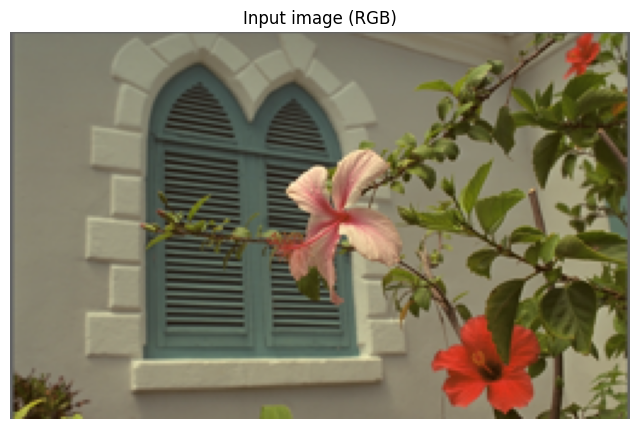

In [37]:
image_index = 0
MAX_SIDE    = 256

def load_rgb(path, max_side=MAX_SIDE):
  img = Image.open(path).convert("RGB")
  img.thumbnail((max_side, max_side))
  w, h = (img.width // 16) * 16, (img.height // 16) * 16
  img = img.crop((0, 0, w, h))
  return np.asarray(img, dtype=np.float64)

rgb = load_rgb(image_paths[image_index])
H, W, C = rgb.shape
print(f"Image shape: {H} x {W} pixels, {C} channels (R,G,B), 8 bits each")
print(f"Raw size: {H*W*C:,} bytes")

plt.figure(figsize=(8,8))
plt.imshow(rgb.astype(np.uint8))
plt.title("Input image (RGB)")
plt.axis("off")
plt.show()

# Step 1: Color Space Conversion (from RGB to YCbCr)

- As far as JPEG is concerned, is that the image’s brightness information is spread evenly through the R, G, and B channels.
- Since brightness is more important than colour, so we’ll want to isolate brightness from the colour information so we can deal with it separately.
- To do this, JPEG uses some math to convert the image’s colour space from RGB to YCbCr.
- A YCbCr image also has three channels, but it stores all of the brightness information in one channel (Y) while splitting the colour information between the other two (Cb and Cr).

Reference: (https://cgjennings.ca/articles/jpeg-compression) (https://en.wikipedia.org/wiki/YCbCr)

In [38]:
def rgb_to_ycbcr(rgb):
  R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
  Y = 0.299 * R + 0.587 * G + 0.114 * B
  Cb = -0.1687 * R - 0.3313 * G + 0.5 * B + 128
  Cr = 0.5 * R - 0.4187 * G - 0.0813 * B + 128
  return Y, Cb, Cr

Y, Cb, Cr = rgb_to_ycbcr(rgb)

py, px = H // 2, W // 2   # To locate the center pixel position
r, g, b = rgb[py, px]
print(f"Pixel at location x={py}, y={px}:")
print(f"RGB = ({r:.0f}, {g:.0f}, {b:.0f})")
print(f"Y = 0.299*{r:.0f} + 0.587*{g:.0f} + 0.114*{b:.0f} = {Y[py,px]:.2f}")
print(f"Cb = -0.1687*{r:.0f} - 0.3313*{g:.0f} + 0.5*{b:.0f} + 128 = {Cb[py,px]:.2f}")
print(f"Cr = 0.5*{r:.0f} - 0.4187*{g:.0f} - 0.0813*{b:.0f} + 128 = {Cr[py,px]:.2f}")

Pixel at location x=80, y=128:
RGB = (149, 62, 60)
Y = 0.299*149 + 0.587*62 + 0.114*60 = 87.78
Cb = -0.1687*149 - 0.3313*62 + 0.5*60 + 128 = 112.32
Cr = 0.5*149 - 0.4187*62 - 0.0813*60 + 128 = 171.66


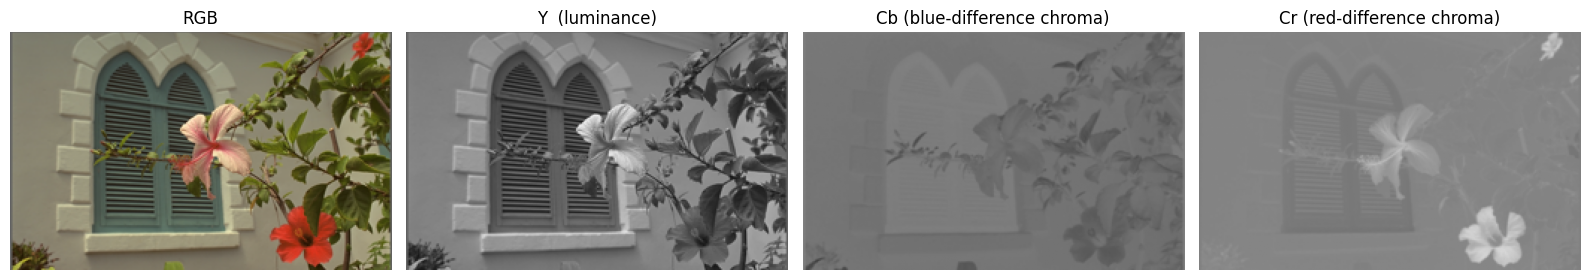

In [39]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(rgb.astype(np.uint8)); ax[0].set_title("RGB")
ax[1].imshow(Y, cmap="gray", vmin=0, vmax=255); ax[1].set_title("Y  (luminance)")
ax[2].imshow(Cb, cmap="gray", vmin=0, vmax=255); ax[2].set_title("Cb (blue-difference chroma)")
ax[3].imshow(Cr, cmap="gray", vmin=0, vmax=255); ax[3].set_title("Cr (red-difference chroma)")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

# (Optional) Step 2: Chrominance Downsampling

- Divide both Cb and Cr components into 2x2 blocks
- Calculate the average of pixel values inside 2x2 blocks

Y : (160, 256) -> 40,960 samples (kept in full)
Cb : (160, 256) -> (80, 128) = 10,240 samples (1/4)
Cr : (160, 256) -> (80, 128) = 10,240 samples (1/4)

Total samples: 122,880 -> 61,440 (50% of original)


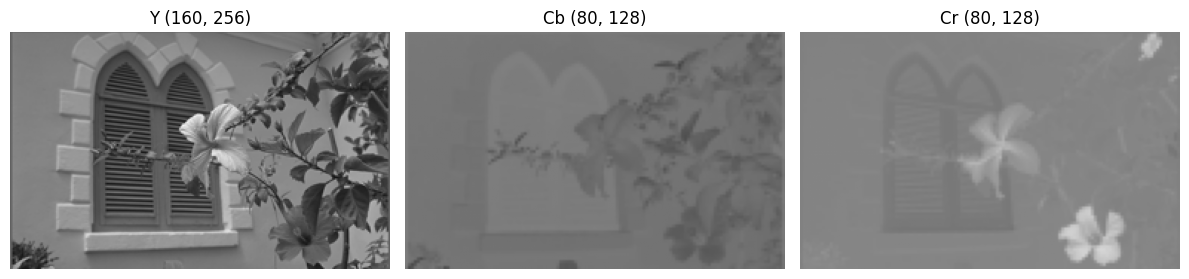

In [40]:
def downsample_420(C):
  return C.reshape(C.shape[0]//2, 2, C.shape[1]//2, 2).mean(axis=(1, 3))

Cb_ds, Cr_ds = downsample_420(Cb), downsample_420(Cr)

print(f"Y : {Y.shape} -> {Y.size:,} samples (kept in full)")
print(f"Cb : {Cb.shape} -> {Cb_ds.shape} = {Cb_ds.size:,} samples (1/4)")
print(f"Cr : {Cr.shape} -> {Cr_ds.shape} = {Cr_ds.size:,} samples (1/4)")
total_before, total_after = Y.size + Cb.size + Cr.size, Y.size + Cb_ds.size + Cr_ds.size
print(f"\nTotal samples: {total_before:,} -> {total_after:,} ({100*total_after/total_before:.0f}% of original)")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(Y, cmap="gray", vmin=0, vmax=255); ax[0].set_title(f"Y {Y.shape}")
ax[1].imshow(Cb_ds, cmap="gray", vmin=0, vmax=255); ax[1].set_title(f"Cb {Cb_ds.shape}")
ax[2].imshow(Cr_ds, cmap="gray", vmin=0, vmax=255); ax[2].set_title(f"Cr {Cr_ds.shape}")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

# Step 3: Discrete Cosine Transform (DCT)

## Step 3.1: Dividing components into 8x8 blocks

From the paper,

> At the input to the encoder, source image samples are
grouped into 8x8 blocks, shifted from unsigned integers
with range [0, 2P - 1] to signed integers with range
[-2P-1, 2P-1-1], and input to the Forward DCT (FDCT).



Y  blocks : 20 x 32 = 640 blocks of 8x8
Cb blocks : 10 x 16 = 160 blocks of 8x8
Cr blocks : 10 x 16 = 160 blocks of 8x8


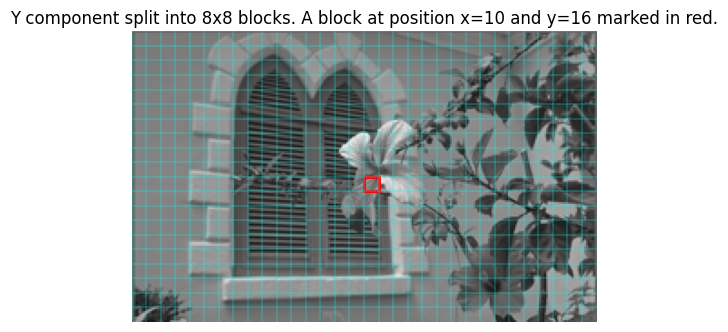

In [41]:
def to_blocks(C):
  h, w = C.shape
  return C.reshape(h//8, 8, w//8, 8).transpose(0, 2, 1, 3)

Yb, Cbb, Crb = to_blocks(Y), to_blocks(Cb_ds), to_blocks(Cr_ds)
print(f"Y  blocks : {Yb.shape[0]} x {Yb.shape[1]} = {Yb.shape[0]*Yb.shape[1]} blocks of 8x8")
print(f"Cb blocks : {Cbb.shape[0]} x {Cbb.shape[1]} = {Cbb.shape[0]*Cbb.shape[1]} blocks of 8x8")
print(f"Cr blocks : {Crb.shape[0]} x {Crb.shape[1]} = {Crb.shape[0]*Crb.shape[1]} blocks of 8x8")

BR, BC = Yb.shape[0] // 2, Yb.shape[1] // 2

plt.figure(figsize=(6, 6)); plt.imshow(Y, cmap="gray", vmin=0, vmax=255)
for x in range(0, W, 8): plt.axvline(x - .5, color="cyan", lw=.3)
for y in range(0, H, 8): plt.axhline(y - .5, color="cyan", lw=.3)
plt.gca().add_patch(plt.Rectangle((BC*8-.5, BR*8-.5), 8, 8, fill=False, color="red", lw=2))
plt.title(f"Y component split into 8x8 blocks. A block at position x={BR} and y={BC} marked in red."); plt.axis("off"); plt.show()

### 3.2 The forward DCT (FDCT) — equation (1) of the paper

Each 8×8 block of samples $f(x,y)$ is first **level-shifted** by subtracting $2^{P-1}=128$ (for 8-bit samples), so that the
values are centred on zero. The block is then fed to the FDCT:

$$
F(u,v) \;=\; \frac{1}{4}\,C(u)\,C(v)\sum_{x=0}^{7}\sum_{y=0}^{7} f(x,y)\,
\cos\frac{(2x+1)u\pi}{16}\,\cos\frac{(2y+1)v\pi}{16},
\qquad C(u),C(v)=\begin{cases}1/\sqrt{2} & u,v=0\\ 1 & \text{otherwise}\end{cases}
$$

The output is 64 **DCT coefficients**. $F(0,0)$ is the **DC coefficient** (the block's average), the other 63 are
**AC coefficients**. Low-frequency coefficients sit near the top-left, high frequencies toward the bottom-right.

In [42]:
def C_(u):
  return 1/np.sqrt(2) if u == 0 else 1.0

# Pre-compute the 8x8 cosine matrix so the FDCT is a fast matrix product:  F = T f T^T
T = np.zeros((8, 8))
for u in range(8):
  for x in range(8):
    T[u, x] = 0.5 * C_(u) * np.cos((2*x + 1) * u * np.pi / 16)

def fdct(block):        # block must already be level-shifted
  return T @ block @ T.T

# Reference (slow) implementation straight from equation (1) — used once to prove equivalence
def fdct_reference(f):
  F = np.zeros((8, 8))
  for u in range(8):
    for v in range(8):
      s = 0.0
      for x in range(8):
        for y in range(8):
          s += f[x, y] * np.cos((2*x+1)*u*np.pi/16) * np.cos((2*y+1)*v*np.pi/16)
      F[u, v] = 0.25 * C_(u) * C_(v) * s
  return F

### 3.3 The 64 DCT basis images
The FDCT can be understood as expressing the block as a **weighted sum of 64 fixed patterns** (the *basis images*).
Basis image $(u,v)$ is

$$
B_{u,v}(x,y) \;=\; \frac{1}{4}\,C(u)\,C(v)\cos\frac{(2x+1)u\pi}{16}\cos\frac{(2y+1)v\pi}{16}
$$

and the coefficient $F(u,v)$ is simply "how much of pattern $B_{u,v}$ is present in this block".

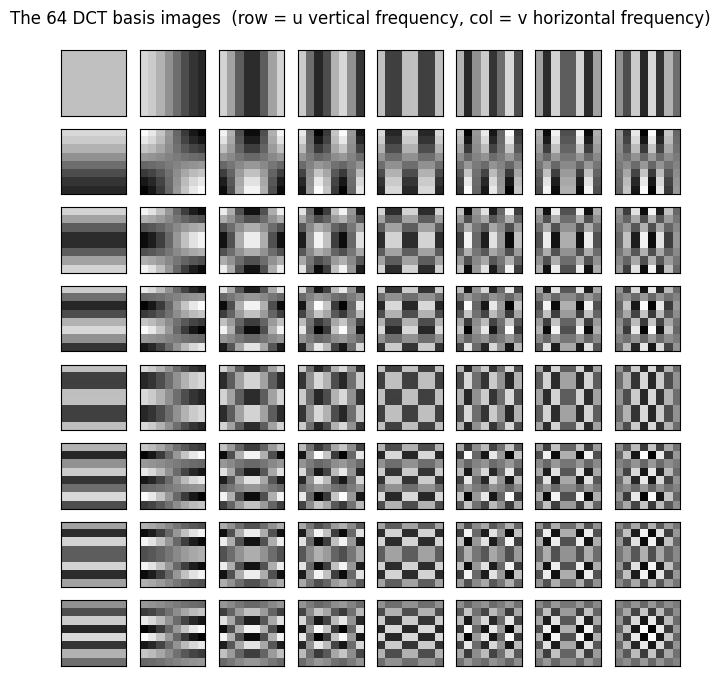

Top-left = constant (DC).  Moving right/down the patterns oscillate faster (higher spatial frequency).


In [43]:
basis = np.zeros((8, 8, 8, 8))            # basis[u, v] is an 8x8 image
for u in range(8):
  for v in range(8):
    basis[u, v] = np.outer(T[u], T[v])

# print(basis.min())
# print(basis.max())

fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for u in range(8):
  for v in range(8):
    ax[u, v].imshow(basis[u, v], cmap="gray", vmin=-0.25, vmax=0.25); ax[u, v].set_xticks([]); ax[u, v].set_yticks([])
fig.suptitle("The 64 DCT basis images  (row = u vertical frequency, col = v horizontal frequency)", y=0.93)
plt.show()
print("Top-left = constant (DC).  Moving right/down the patterns oscillate faster (higher spatial frequency).")

### 3.4 FDCT on one luminance block

In [44]:
blockY = Yb[BR, BC]
print("Selected 8x8 Y block — original samples f(x,y):")
print(np.round(blockY).astype(int))

shiftedY = blockY - 128
print("\nAfter level shift (subtract 128):")
print(np.round(shiftedY).astype(int))

FY = fdct(shiftedY)
print("\nFDCT output F(u,v) — DC coefficient top-left, 63 AC coefficients:")
print(np.round(FY, 1))
print(f"\nMax difference between fast and reference eq.(1) implementation: {np.abs(FY - fdct_reference(shiftedY)).max():.2e}")

Selected 8x8 Y block — original samples f(x,y):
[[ 88  83  90 110 126 123  93 105]
 [ 93 126 149 147 123 113  91 111]
 [149 156 132 120 132 112  88 143]
 [169 121 127 141 120 106 103 145]
 [114 140 148 126 114 106 115 118]
 [138 137 124 124 111 109 120 138]
 [131 130 132 116 111 117 143 176]
 [131 139 117 112 112 130 151 126]]

After level shift (subtract 128):
[[-40 -45 -38 -18  -2  -5 -35 -23]
 [-35  -2  21  19  -5 -15 -37 -17]
 [ 21  28   4  -8   4 -16 -40  15]
 [ 41  -7  -1  13  -8 -22 -25  17]
 [-14  12  20  -2 -14 -22 -13 -10]
 [ 10   9  -4  -4 -17 -19  -8  10]
 [  3   2   4 -12 -17 -11  15  48]
 [  3  11 -11 -16 -16   2  23  -2]]

FDCT output F(u,v) — DC coefficient top-left, 63 AC coefficients:
[[-37.6  21.7  21.1 -33.6  18.3 -16.2   8.9  -6.4]
 [-44.9  15.6 -57.1   1.   23.4 -18.1  17.3  -6.8]
 [-30.6 -46.1 -18.   20.4 -20.8   1.2  -6.1  -2. ]
 [-36.2 -24.3 -18.   -3.8  -7.2   7.1  -0.8   1.7]
 [-24.2  -8.7 -10.6  25.5  -2.3  16.8  -3.6   3.3]
 [  6.6 -20.1  35.7  14.2  36.6  

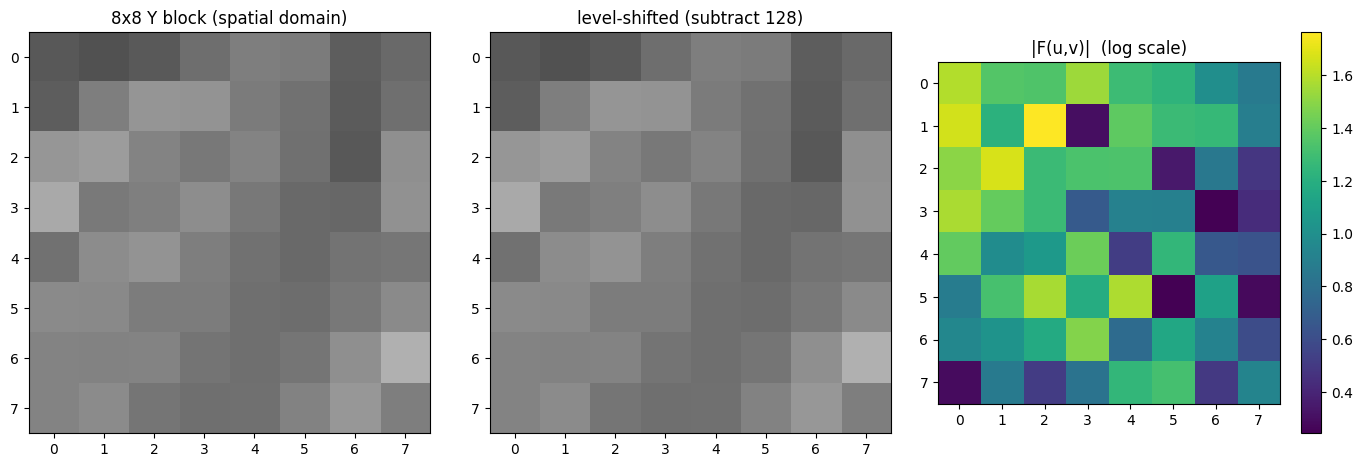

Most of the energy is concentrated in a few low-frequency coefficients near the top-left corner.
Energy in the DC coefficient alone: 5.7%  of the block's total energy.


In [45]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
ax[0].imshow(blockY, cmap="gray", vmin=0, vmax=255); ax[0].set_title("8x8 Y block (spatial domain)")
ax[1].imshow(shiftedY, cmap="gray", vmin=-128, vmax=127); ax[1].set_title("level-shifted (subtract 128)")
im = ax[2].imshow(np.log10(np.abs(FY) + 1), cmap="viridis"); ax[2].set_title("|F(u,v)|  (log scale)")
for a in ax: a.set_xticks(range(8)); a.set_yticks(range(8))
plt.colorbar(im, ax=ax[2]); plt.tight_layout(); plt.show()

print("Most of the energy is concentrated in a few low-frequency coefficients near the top-left corner.")
print(f"Energy in the DC coefficient alone: {100*FY[0,0]**2/np.sum(FY**2):.1f}%  of the block's total energy.")

### 3.5 FDCT on the chrominance blocks
The chrominance components go through exactly the same procedure. Because they were downsampled, one C<sub>b</sub>
(or C<sub>r</sub>) block now covers a **16×16** pixel area, the same area as *four* Y blocks.

In [46]:
CBR, CBC = BR // 2, BC // 2         # the chroma block that covers the chosen Y block
blockCb, blockCr = Cbb[CBR, CBC], Crb[CBR, CBC]
FCb, FCr = fdct(blockCb - 128), fdct(blockCr - 128)

for name, blk, F in [("Cb", blockCb, FCb), ("Cr", blockCr, FCr)]:
  print(f"{name} block (x={CBR}, y={CBC})")
  print("original samples:")
  print(np.round(blk).astype(int))
  print("level-shifted (subtract 128):")
  print(np.round(blk - 128).astype(int))
  print("FDCT coefficients:")
  print(np.round(F, 1))
  print()

Cb block (x=5, y=8)
original samples:
[[111 109 109 108 102 103 104 107]
 [109 109 112 109 103 101 101 102]
 [108 111 113 111 119 114 101 101]
 [110 112 113 109 110  98 101 102]
 [110 112 112 114 114 104 108 104]
 [111 112 109 117 103 111 116 110]
 [111 112 110 122 122 125 118 111]
 [110 111 112 124 124 125 119 111]]
level-shifted (subtract 128):
[[-17 -19 -19 -20 -26 -25 -24 -21]
 [-19 -19 -16 -19 -25 -27 -27 -26]
 [-20 -17 -15 -17  -9 -14 -27 -27]
 [-18 -16 -15 -19 -18 -30 -27 -26]
 [-18 -16 -16 -14 -14 -24 -20 -24]
 [-17 -16 -19 -11 -25 -17 -12 -18]
 [-17 -16 -18  -6  -6  -3 -10 -17]
 [-18 -17 -16  -4  -4  -3  -9 -17]]
FDCT coefficients:
[[-140.6   10.   -14.4    0.6    1.5    2.7   -3.1   -3.1]
 [ -29.    16.3    9.2   -8.8    1.1   -4.4    4.7    5. ]
 [  10.2  -10.1   -1.5    4.6   -0.3    2.8    3.4   -5.6]
 [  -5.3   -0.6   12.7   -5.7   -1.     6.9   -3.2   -4.2]
 [  -2.8    3.1    1.8   -2.9    2.7   -0.9   -2.2    4.4]
 [   3.5   -2.    -0.3    2.9    0.6   -2.8    1.    -0.

### 3.6 Final output of the DCT step for the whole image
Now apply level-shift + FDCT to **every** block of all three components.
Displaying the DC coefficient of every block gives a thumbnail (the block averages); displaying the log-magnitude of all
coefficients shows how sparse the transform domain is.

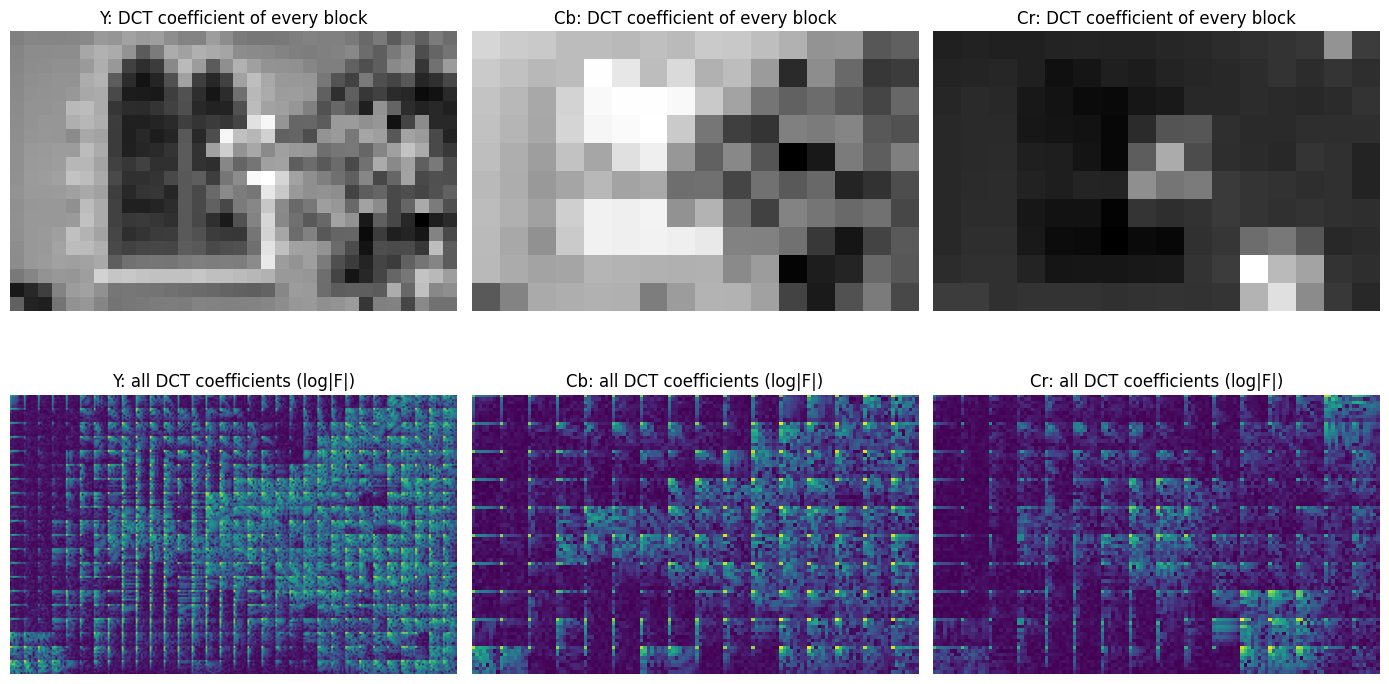

DCT coefficients so far are real numbers, no information has been lost yet (the DCT is invertible).


In [47]:
def fdct_all(blocks):
  out = np.empty_like(blocks)
  for i in range(blocks.shape[0]):
    for j in range(blocks.shape[1]):
      out[i, j] = fdct(blocks[i, j] - 128)
  return out

def from_blocks(blocks):     # inverse of to_blocks, for visualisation
  r, c = blocks.shape[:2]
  return blocks.transpose(0, 2, 1, 3).reshape(r*8, c*8)

FYb, FCbb, FCrb = fdct_all(Yb), fdct_all(Cbb), fdct_all(Crb)

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for k, (name, F) in enumerate([("Y", FYb), ("Cb", FCbb), ("Cr", FCrb)]):
  ax[0, k].imshow(F[:, :, 0, 0], cmap="gray"); ax[0, k].set_title(f"{name}: DCT coefficient of every block")
  ax[1, k].imshow(np.log10(np.abs(from_blocks(F)) + 1), cmap="viridis"); ax[1, k].set_title(f"{name}: all DCT coefficients (log|F|)")
for a in ax.ravel(): a.axis("off")
plt.tight_layout()
plt.show()
print("DCT coefficients so far are real numbers, no information has been lost yet (the DCT is invertible).")

## 4. Quantization

This is where the **lossy** part of JPEG happens. Each of the 64 coefficients is divided by the corresponding entry of a
quantization table $Q(u,v)$ and rounded to the nearest integer:

$$
F^{Q}(u,v) \;=\; \text{round}\!\left(\frac{F(u,v)}{Q(u,v)}\right)
$$

Large $Q$ entries (for high frequencies the eye can't see well) send most coefficients to **zero**, which is what makes the
subsequent entropy coding so effective.

References for quantization table: https://www.w3.org/Graphics/JPEG/itu-t81.pdf$0 (Page 143).

A **quality factor** scales the tables
(the standard: quality 50 = the tables as printed).

In [48]:
Q_LUM = np.array([
    [16, 11, 10, 16,  24,  40,  51,  61],
    [12, 12, 14, 19,  26,  58,  60,  55],
    [14, 13, 16, 24,  40,  57,  69,  56],
    [14, 17, 22, 29,  51,  87,  80,  62],
    [18, 22, 37, 56,  68, 109, 103,  77],
    [24, 35, 55, 64,  81, 104, 113,  92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103,  99]])

Q_CHR = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]])

def scale_table(Q, quality):    #to correspond the table values w.r.t quality adjustment
  quality = max(1, min(100, quality))
  s = 5000 / quality if quality < 50 else 200 - 2 * quality
  return np.clip(np.floor((Q * s + 50) / 100), 1, 255).astype(int)

QUALITY = 50  # try 10, 50, 90 and compare the results
QY, QC = scale_table(Q_LUM, QUALITY), scale_table(Q_CHR, QUALITY)

print(f"Luminance quantization table (quality={QUALITY}):");   print(QY)
print(f"\nChrominance quantization table (quality={QUALITY}):"); print(QC)

Luminance quantization table (quality=50):
[[ 16  11  10  16  24  40  51  61]
 [ 12  12  14  19  26  58  60  55]
 [ 14  13  16  24  40  57  69  56]
 [ 14  17  22  29  51  87  80  62]
 [ 18  22  37  56  68 109 103  77]
 [ 24  35  55  64  81 104 113  92]
 [ 49  64  78  87 103 121 120 101]
 [ 72  92  95  98 112 100 103  99]]

Chrominance quantization table (quality=50):
[[17 18 24 47 99 99 99 99]
 [18 21 26 66 99 99 99 99]
 [24 26 56 99 99 99 99 99]
 [47 66 99 99 99 99 99 99]
 [99 99 99 99 99 99 99 99]
 [99 99 99 99 99 99 99 99]
 [99 99 99 99 99 99 99 99]
 [99 99 99 99 99 99 99 99]]


In [49]:
def quantize(F, Q):
  return np.round(F / Q).astype(int)

qY, qCb, qCr = quantize(FY, QY), quantize(FCb, QC), quantize(FCr, QC)

print("Y block: DCT coefficients F(u,v)"); print(np.round(FY, 1))
print("\nDivided by Q(u,v), rounded  ->  quantized F^Q(u,v)"); print(qY)
print(f"\nNon-zero coefficients: {np.count_nonzero(qY)} of 64")

print("\nCb block quantized:"); print(qCb); print(f"Non-zero: {np.count_nonzero(qCb)} of 64")
print("\nCr block quantized:"); print(qCr); print(f"Non-zero: {np.count_nonzero(qCr)} of 64")

Y block: DCT coefficients F(u,v)
[[-37.6  21.7  21.1 -33.6  18.3 -16.2   8.9  -6.4]
 [-44.9  15.6 -57.1   1.   23.4 -18.1  17.3  -6.8]
 [-30.6 -46.1 -18.   20.4 -20.8   1.2  -6.1  -2. ]
 [-36.2 -24.3 -18.   -3.8  -7.2   7.1  -0.8   1.7]
 [-24.2  -8.7 -10.6  25.5  -2.3  16.8  -3.6   3.3]
 [  6.6 -20.1  35.7  14.2  36.6   0.8  11.9   0.9]
 [ -7.9   9.6  13.8  29.4   5.  -13.3  -7.2  -3. ]
 [ -0.9  -6.3   2.3  -5.7 -16.7 -19.6  -2.1   7.5]]

Divided by Q(u,v), rounded  ->  quantized F^Q(u,v)
[[-2  2  2 -2  1  0  0  0]
 [-4  1 -4  0  1  0  0  0]
 [-2 -4 -1  1 -1  0  0  0]
 [-3 -1 -1  0  0  0  0  0]
 [-1  0  0  0  0  0  0  0]
 [ 0 -1  1  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]

Non-zero coefficients: 20 of 64

Cb block quantized:
[[-8  1 -1  0  0  0  0  0]
 [-2  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]
Non-zero: 5 of 64


Y : 7,399 non-zero of 40,960 coefficients (18.1%)
Cb: 469 non-zero of 10,240 coefficients (4.6%)
Cr: 337 non-zero of 10,240 coefficients (3.3%)


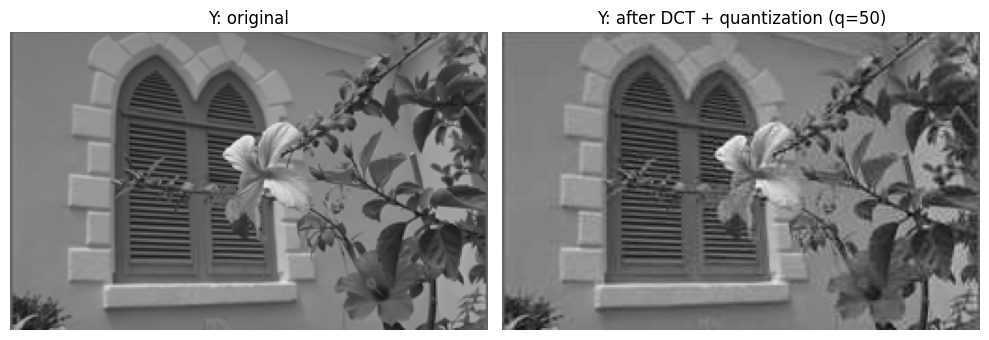

In [50]:
# quantize every block of the image
def quantize_all(Fb, Q):
  return np.round(Fb / Q).astype(int)

qYb, qCbb, qCrb = quantize_all(FYb, QY), quantize_all(FCbb, QC), quantize_all(FCrb, QC)

nz = lambda a: np.count_nonzero(a)
print(f"Y : {nz(qYb):,} non-zero of {qYb.size:,} coefficients ({100*nz(qYb)/qYb.size:.1f}%)")
print(f"Cb: {nz(qCbb):,} non-zero of {qCbb.size:,} coefficients ({100*nz(qCbb)/qCbb.size:.1f}%)")
print(f"Cr: {nz(qCrb):,} non-zero of {qCrb.size:,} coefficients ({100*nz(qCrb)/qCrb.size:.1f}%)")

# what the image would look like after only these lossy steps (preview via inverse DCT)
def idct(F): return T.T @ F @ T
def reconstruct(qb, Q):
    out = np.empty_like(qb, dtype=float)
    for i in range(qb.shape[0]):
        for j in range(qb.shape[1]):
            out[i, j] = idct(qb[i, j] * Q) + 128
    return from_blocks(out)

Yr = reconstruct(qYb, QY)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(Y, cmap="gray", vmin=0, vmax=255);  ax[0].set_title("Y: original")
ax[1].imshow(np.clip(Yr, 0, 255), cmap="gray", vmin=0, vmax=255); ax[1].set_title(f"Y: after DCT + quantization (q={QUALITY})")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 5. DC coding and the Zig-Zag sequence

After quantization the 64 coefficients are prepared for entropy coding in two ways:

1. **DC differencing (DPCM).** The DC coefficient is the block average, and neighbouring blocks have very similar
   averages. So instead of coding $DC_i$ directly, JPEG codes the difference from the previous block of the same component:
   $$\text{DIFF}_i = DC_i - DC_{i-1}\qquad(\text{with }DC_{-1}=0)$$
2. **Zig-zag ordering.** The 63 AC coefficients are read in a zig-zag pattern from low to high frequency.
   Since high frequencies are mostly zero after quantization, this places the zeros at the *end* of the sequence,
   producing long runs that are cheap to encode.

Reference: https://www.w3.org/Graphics/JPEG/itu-t81.pdf$0 (Page: 30)

Zig-zag index map (the order in which the 64 positions are read):
[[ 0  1  5  6 14 15 27 28]
 [ 2  4  7 13 16 26 29 42]
 [ 3  8 12 17 25 30 41 43]
 [ 9 11 18 24 31 40 44 53]
 [10 19 23 32 39 45 52 54]
 [20 22 33 38 46 51 55 60]
 [21 34 37 47 50 56 59 61]
 [35 36 48 49 57 58 62 63]]


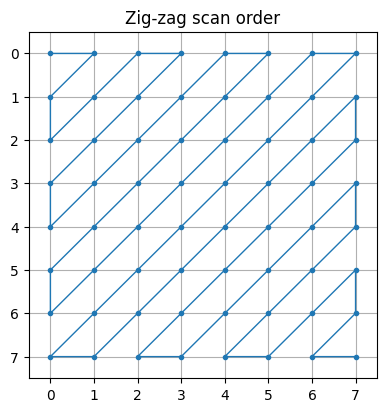

In [51]:
ZIGZAG = np.array([
    [ 0,  1,  5,  6, 14, 15, 27, 28],
    [ 2,  4,  7, 13, 16, 26, 29, 42],
    [ 3,  8, 12, 17, 25, 30, 41, 43],
    [ 9, 11, 18, 24, 31, 40, 44, 53],
    [10, 19, 23, 32, 39, 45, 52, 54],
    [20, 22, 33, 38, 46, 51, 55, 60],
    [21, 34, 37, 47, 50, 56, 59, 61],
    [35, 36, 48, 49, 57, 58, 62, 63]])
ZZ_ORDER = np.argsort(ZIGZAG.ravel())          # index list: position k -> raster index

def zigzag(block):
  return block.ravel()[ZZ_ORDER]

print("Zig-zag index map (the order in which the 64 positions are read):"); print(ZIGZAG)

# draw the path
fig, ax = plt.subplots(figsize=(4.5, 4.5))
pts = [(np.argwhere(ZIGZAG == k)[0][1], np.argwhere(ZIGZAG == k)[0][0]) for k in range(64)]
ax.plot([p[0] for p in pts], [p[1] for p in pts], "-o", ms=3, lw=1)
ax.set_xlim(-.5, 7.5); ax.set_ylim(7.5, -.5); ax.set_xticks(range(8)); ax.set_yticks(range(8)); ax.grid(True)
ax.set_title("Zig-zag scan order")
plt.show()

## 6. Entropy Coding

## 6.1 Intermediate (interleaved) representation


In [52]:
zzY = zigzag(qY)
print("Quantized Y block:"); print(qY)
print("\nZig-zag sequence (DC first, then 63 AC coefficients):")
print(zzY)

# trailing zeros after the last non-zero
last = np.max(np.nonzero(zzY)) if np.any(zzY) else 0
print(f"\nLast non-zero coefficient at zig-zag position {last} -> {63 - last} trailing zeros will be coded with a single EOB symbol.")

# DC differencing along the sequence of Y blocks (raster order in this simplified view)
dc_seq = qYb[:, :, 0, 0].ravel()
diffs  = np.diff(np.concatenate([[0], dc_seq]))
print("\nDC coefficients of the first 12 Y blocks :", dc_seq[:12])
print("DC differences (DIFF) of the same blocks  :", diffs[:12])
print(f"\n|DC| mean = {np.abs(dc_seq).mean():.1f}   vs   |DIFF| mean = {np.abs(diffs).mean():.1f}   -> smaller numbers, fewer bits")

Quantized Y block:
[[-2  2  2 -2  1  0  0  0]
 [-4  1 -4  0  1  0  0  0]
 [-2 -4 -1  1 -1  0  0  0]
 [-3 -1 -1  0  0  0  0  0]
 [-1  0  0  0  0  0  0  0]
 [ 0 -1  1  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]

Zig-zag sequence (DC first, then 63 AC coefficients):
[-2  2 -4 -2  1  2 -2 -4 -4 -3 -1 -1 -1  0  1  0  1  1 -1  0  0  0 -1  0
  0 -1  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

Last non-zero coefficient at zig-zag position 33 -> 30 trailing zeros will be coded with a single EOB symbol.

DC coefficients of the first 12 Y blocks : [-6 -4 -4 -4 -4 -3  2  0  4  2  3 -2]
DC differences (DIFF) of the same blocks  : [-6  2  0  0  0  1  5 -2  4 -2  1 -5]

|DC| mean = 13.0   vs   |DIFF| mean = 8.0   -> smaller numbers, fewer bits


In [53]:
def size_category(v):
  v = abs(int(v)); return 0 if v == 0 else v.bit_length()

def vli_bits(v):
  '''Amplitude bits (Table 3 of the paper): positive -> binary, negative -> one's complement.'''
  s = size_category(v)
  if s == 0: return ""
  if v > 0: return format(v, f"0{s}b")
  return format((1 << s) + v - 1, f"0{s}b")

print("Table 3 style examples (value -> SIZE, amplitude bits):")
for v in [0, 1, -1, 2, 3, -3, 5, -5, 17, -33]:
  print(f"   {v:4d} -> SIZE {size_category(v)}, bits {vli_bits(v)!r}")

def block_symbols(zz, prev_dc):
  '''Convert one zig-zag block into the intermediate symbol sequence.'''
  diff = int(zz[0]) - prev_dc
  syms = [("DC", size_category(diff), diff)]
  run = 0
  for k in range(1, 64):
    v = int(zz[k])
    if v == 0:
      run += 1
      continue
    while run > 15:
      syms.append(("AC", (15, 0), None)); run -= 16  # ZRL
    syms.append(("AC", (run, size_category(v)), v)); run = 0
  if run > 0 or all(zz[1:] == 0):
    syms.append(("AC", (0, 0), None))  # EOB
  return syms, int(zz[0])

symsY, _ = block_symbols(zzY, prev_dc=0)
print("\nIntermediate symbols for the selected Y block (assuming previous DC = 0):")
for kind, s1, s2 in symsY:
  if kind == "DC":
    print(f"DC : SIZE={s1:<2} amplitude={s2:<4} bits={vli_bits(s2)!r}")
  elif s1 == (0,0):
    print("AC : EOB")
  elif s1 == (15,0):
    print("AC : ZRL (16 zeros)")
  else:
    print(f"AC : (RUN={s1[0]:<2}, SIZE={s1[1]}) amplitude={s2:<4} bits={vli_bits(s2)!r}")

Table 3 style examples (value -> SIZE, amplitude bits):
      0 -> SIZE 0, bits ''
      1 -> SIZE 1, bits '1'
     -1 -> SIZE 1, bits '0'
      2 -> SIZE 2, bits '10'
      3 -> SIZE 2, bits '11'
     -3 -> SIZE 2, bits '00'
      5 -> SIZE 3, bits '101'
     -5 -> SIZE 3, bits '010'
     17 -> SIZE 5, bits '10001'
    -33 -> SIZE 6, bits '011110'

Intermediate symbols for the selected Y block (assuming previous DC = 0):
DC : SIZE=2  amplitude=-2   bits='01'
AC : (RUN=0 , SIZE=2) amplitude=2    bits='10'
AC : (RUN=0 , SIZE=3) amplitude=-4   bits='011'
AC : (RUN=0 , SIZE=2) amplitude=-2   bits='01'
AC : (RUN=0 , SIZE=1) amplitude=1    bits='1'
AC : (RUN=0 , SIZE=2) amplitude=2    bits='10'
AC : (RUN=0 , SIZE=2) amplitude=-2   bits='01'
AC : (RUN=0 , SIZE=3) amplitude=-4   bits='011'
AC : (RUN=0 , SIZE=3) amplitude=-4   bits='011'
AC : (RUN=0 , SIZE=2) amplitude=-3   bits='00'
AC : (RUN=0 , SIZE=1) amplitude=-1   bits='0'
AC : (RUN=0 , SIZE=1) amplitude=-1   bits='0'
AC : (RUN=0 , SIZE=

### From the paper

> When two or more components are interleaved, each component C_{i} is partitioned into rectangular regions of H_{i} by V_{i} data units


In [54]:
# ---- build the interleaved MCU order for the whole image -------------------
def mcu_sequence(qYb, qCbb, qCrb):
    '''Yields (component, block) in MCU-interleaved order: Y0 Y1 Y2 Y3 Cb Cr per 16x16 area.'''
    for mi in range(qCbb.shape[0]):
        for mj in range(qCbb.shape[1]):
            yield "Y",  qYb[2*mi,   2*mj]
            yield "Y",  qYb[2*mi,   2*mj+1]
            yield "Y",  qYb[2*mi+1, 2*mj]
            yield "Y",  qYb[2*mi+1, 2*mj+1]
            yield "Cb", qCbb[mi, mj]
            yield "Cr", qCrb[mi, mj]

n_mcu = qCbb.shape[0] * qCbb.shape[1]
print(f"Image = {qCbb.shape[0]} x {qCbb.shape[1]} = {n_mcu} MCUs; each MCU = 6 blocks (4 Y + Cb + Cr)")
print("Interleaved block order of the first MCU :", [c for c, _ in list(mcu_sequence(qYb, qCbb, qCrb))[:6]])

# convert every block to symbols, keeping a separate DC predictor per component
all_symbols = []
prev = {"Y": 0, "Cb": 0, "Cr": 0}
for comp, blk in mcu_sequence(qYb, qCbb, qCrb):
    syms, prev[comp] = block_symbols(zigzag(blk), prev[comp])
    all_symbols.append((comp, syms))

total_syms = sum(len(s) for _, s in all_symbols)
print(f"\nTotal blocks: {len(all_symbols)},  total intermediate symbols: {total_syms:,}")
print(f"(compare: {len(all_symbols)*64:,} raw coefficients — run-lengths and EOB already removed most zeros)")

Image = 10 x 16 = 160 MCUs; each MCU = 6 blocks (4 Y + Cb + Cr)
Interleaved block order of the first MCU : ['Y', 'Y', 'Y', 'Y', 'Cb', 'Cr']

Total blocks: 960,  total intermediate symbols: 9,206
(compare: 61,440 raw coefficients — run-lengths and EOB already removed most zeros)


## 6.2 Huffman coding with the standard variable-length code (VLC) tables

Baseline JPEG uses **four tables**: DC-luminance, DC-chrominance, AC-luminance, AC-chrominance.

Reference: https://www.w3.org/Graphics/JPEG/itu-t81.pdf$0 (Page: 158)

These arrays come directly from the ISO/IEC JPEG specification (Annex K.3.3)

In [55]:
# Annex K "typical" Huffman tables (BITS, HUFFVAL)
DC_LUM_BITS = [0,1,5,1,1,1,1,1,1,0,0,0,0,0,0,0];
DC_LUM_VAL = list(range(12))
DC_CHR_BITS = [0,3,1,1,1,1,1,1,1,1,1,0,0,0,0,0];
DC_CHR_VAL = list(range(12))

AC_LUM_BITS = [0,2,1,3,3,2,4,3,5,5,4,4,0,0,1,0x7d]
AC_LUM_VAL  = [
 0x01,0x02,0x03,0x00,0x04,0x11,0x05,0x12,0x21,0x31,0x41,0x06,0x13,0x51,0x61,0x07,0x22,0x71,0x14,0x32,0x81,0x91,0xa1,0x08,
 0x23,0x42,0xb1,0xc1,0x15,0x52,0xd1,0xf0,0x24,0x33,0x62,0x72,0x82,0x09,0x0a,0x16,0x17,0x18,0x19,0x1a,0x25,0x26,0x27,0x28,
 0x29,0x2a,0x34,0x35,0x36,0x37,0x38,0x39,0x3a,0x43,0x44,0x45,0x46,0x47,0x48,0x49,0x4a,0x53,0x54,0x55,0x56,0x57,0x58,0x59,
 0x5a,0x63,0x64,0x65,0x66,0x67,0x68,0x69,0x6a,0x73,0x74,0x75,0x76,0x77,0x78,0x79,0x7a,0x83,0x84,0x85,0x86,0x87,0x88,0x89,
 0x8a,0x92,0x93,0x94,0x95,0x96,0x97,0x98,0x99,0x9a,0xa2,0xa3,0xa4,0xa5,0xa6,0xa7,0xa8,0xa9,0xaa,0xb2,0xb3,0xb4,0xb5,0xb6,
 0xb7,0xb8,0xb9,0xba,0xc2,0xc3,0xc4,0xc5,0xc6,0xc7,0xc8,0xc9,0xca,0xd2,0xd3,0xd4,0xd5,0xd6,0xd7,0xd8,0xd9,0xda,0xe1,0xe2,
 0xe3,0xe4,0xe5,0xe6,0xe7,0xe8,0xe9,0xea,0xf1,0xf2,0xf3,0xf4,0xf5,0xf6,0xf7,0xf8,0xf9,0xfa]

AC_CHR_BITS = [0,2,1,2,4,4,3,4,7,5,4,4,0,1,2,0x77]
AC_CHR_VAL  = [
 0x00,0x01,0x02,0x03,0x11,0x04,0x05,0x21,0x31,0x06,0x12,0x41,0x51,0x07,0x61,0x71,0x13,0x22,0x32,0x81,0x08,0x14,0x42,0x91,
 0xa1,0xb1,0xc1,0x09,0x23,0x33,0x52,0xf0,0x15,0x62,0x72,0xd1,0x0a,0x16,0x24,0x34,0xe1,0x25,0xf1,0x17,0x18,0x19,0x1a,0x26,
 0x27,0x28,0x29,0x2a,0x35,0x36,0x37,0x38,0x39,0x3a,0x43,0x44,0x45,0x46,0x47,0x48,0x49,0x4a,0x53,0x54,0x55,0x56,0x57,0x58,
 0x59,0x5a,0x63,0x64,0x65,0x66,0x67,0x68,0x69,0x6a,0x73,0x74,0x75,0x76,0x77,0x78,0x79,0x7a,0x82,0x83,0x84,0x85,0x86,0x87,
 0x88,0x89,0x8a,0x92,0x93,0x94,0x95,0x96,0x97,0x98,0x99,0x9a,0xa2,0xa3,0xa4,0xa5,0xa6,0xa7,0xa8,0xa9,0xaa,0xb2,0xb3,0xb4,
 0xb5,0xb6,0xb7,0xb8,0xb9,0xba,0xc2,0xc3,0xc4,0xc5,0xc6,0xc7,0xc8,0xc9,0xca,0xd2,0xd3,0xd4,0xd5,0xd6,0xd7,0xd8,0xd9,0xda,
 0xe2,0xe3,0xe4,0xe5,0xe6,0xe7,0xe8,0xe9,0xea,0xf2,0xf3,0xf4,0xf5,0xf6,0xf7,0xf8,0xf9,0xfa]

def build_huffman_codes(bits, vals):
  '''Canonical Huffman code generation (Annex C of the JPEG spec): returns {symbol: code-string}.'''
  codes, code, k = {}, 0, 0
  for length in range(1, 17):
    for _ in range(bits[length - 1]):
      codes[vals[k]] = format(code, f"0{length}b"); code += 1; k += 1
    code <<= 1
  return codes

HUFF = {"DC_Y": build_huffman_codes(DC_LUM_BITS, DC_LUM_VAL), "DC_C": build_huffman_codes(DC_CHR_BITS, DC_CHR_VAL),
        "AC_Y": build_huffman_codes(AC_LUM_BITS, AC_LUM_VAL), "AC_C": build_huffman_codes(AC_CHR_BITS, AC_CHR_VAL)}

print("DC luminance Huffman table (paper, Table 4):")
print("  SIZE  code")
for s, c in HUFF["DC_Y"].items(): print(f"  {s:<5} {c}")

print("\nA few AC luminance codes (RUN/SIZE -> code):")
for sym in [0x00, 0x01, 0x02, 0x11, 0x03, 0x04, 0x21, 0x12, 0xF0, 0xFA]:
  label = "EOB" if sym == 0 else ("ZRL" if sym == 0xF0 else f"({sym>>4},{sym&15})")
  print(f"  {label:<6} {HUFF['AC_Y'][sym]}")

DC luminance Huffman table (paper, Table 4):
  SIZE  code
  0     00
  1     010
  2     011
  3     100
  4     101
  5     110
  6     1110
  7     11110
  8     111110
  9     1111110
  10    11111110
  11    111111110

A few AC luminance codes (RUN/SIZE -> code):
  EOB    1010
  (0,1)  00
  (0,2)  01
  (1,1)  1100
  (0,3)  100
  (0,4)  1011
  (2,1)  11100
  (1,2)  11011
  ZRL    11111111001
  (15,10) 1111111111111110


In [56]:
def encode_block_bits(syms, comp, trace=False):
  '''Huffman-encode the intermediate symbols of one block into a bit string.'''
  dc_tab = HUFF["DC_Y"] if comp == "Y" else HUFF["DC_C"]
  ac_tab = HUFF["AC_Y"] if comp == "Y" else HUFF["AC_C"]
  bits = ""
  for kind, s1, s2 in syms:
    if kind == "DC":
      code, amp = dc_tab[s1], vli_bits(s2)
      if trace: print(f"DC SIZE={s1:<2} -> VLC {code:<6} + VLI {amp!r}")
    else:
      sym = (s1[0] << 4) | s1[1]
      code, amp = ac_tab[sym], (vli_bits(s2) if s2 is not None else "")
      if trace:
        label = "EOB" if sym == 0 else ("ZRL" if sym == 0xF0 else f"({s1[0]},{s1[1]})")
        print(f"AC {label:<7} -> VLC {code:<6} + VLI {amp!r}")
    bits += code + amp
  return bits

print(f"Huffman coding of the selected Y block (row {BR}, col {BC}), previous DC assumed 0:")
blk_bits = encode_block_bits(symsY, "Y", trace=True)
print(f"\nBit string : {blk_bits}")
print(f"{len(blk_bits)} bits for this compressed block  vs  512 bits raw block (64 samples x 8 bits) -> {512/len(blk_bits):.1f}x smaller")

Huffman coding of the selected Y block (row 10, col 16), previous DC assumed 0:
DC SIZE=2  -> VLC 011    + VLI '01'
AC (0,2)   -> VLC 01     + VLI '10'
AC (0,3)   -> VLC 100    + VLI '011'
AC (0,2)   -> VLC 01     + VLI '01'
AC (0,1)   -> VLC 00     + VLI '1'
AC (0,2)   -> VLC 01     + VLI '10'
AC (0,2)   -> VLC 01     + VLI '01'
AC (0,3)   -> VLC 100    + VLI '011'
AC (0,3)   -> VLC 100    + VLI '011'
AC (0,2)   -> VLC 01     + VLI '00'
AC (0,1)   -> VLC 00     + VLI '0'
AC (0,1)   -> VLC 00     + VLI '0'
AC (0,1)   -> VLC 00     + VLI '0'
AC (1,1)   -> VLC 1100   + VLI '1'
AC (1,1)   -> VLC 1100   + VLI '1'
AC (0,1)   -> VLC 00     + VLI '1'
AC (0,1)   -> VLC 00     + VLI '0'
AC (3,1)   -> VLC 111010 + VLI '0'
AC (2,1)   -> VLC 11100  + VLI '0'
AC (7,1)   -> VLC 11111010 + VLI '1'
AC EOB     -> VLC 1010   + VLI ''

Bit string : 0110101101000110101001011001011000111000110100000000000110011100100100011101001110001111101011010
97 bits for this compressed block  vs  512 bits raw block (6

# 7. The final bitstream

In [57]:
bitstream = "".join(encode_block_bits(syms, comp) for comp, syms in all_symbols)
print(f"Entropy-coded bitstream: {len(bitstream):,} bits = {len(bitstream)/8:,.0f} bytes")
print(f"First 256 bits:\n{bitstream[:256]}")
print("\nSize summary")
print(f"  raw RGB        : {H*W*3:,} bytes")
print(f"  after 4:2:0    : {int(H*W*1.5):,} bytes")
print(f"  coded scan data: {len(bitstream)//8:,} bytes   -> compression ratio {H*W*3/(len(bitstream)/8):.1f} : 1")

Entropy-coded bitstream: 45,456 bits = 5,682 bytes
First 256 bits:
1000011000110101010100110001101010011100000011101001111010010100111011011000101111111101110100011111100101010001000111111111101010110101111110100101001110101010000001100011011101100010111111110111010001111110010101000110110001011111111011101000111111001010

Size summary
  raw RGB        : 122,880 bytes
  after 4:2:0    : 61,440 bytes
  coded scan data: 5,682 bytes   -> compression ratio 21.6 : 1
